# Searching...
**Course:** Data Structures & Algorithms 1

## Implementation

In [1]:
import re

def readFileAndSeparateWords(fileName):
    arrayOfWords = []

    with open(fileName) as f:
        for line in f:
            tempArray = re.findall(r"[a-zA-Z]+(?:'[a-zA-Z]+)*", line.casefold())

            if tempArray:
                arrayOfWords.extend(tempArray)

    return sorted(arrayOfWords)


def LinearCount(word, wordArray):
    count = 0

    for i in range(len(wordArray)):
        if word == wordArray[i]:
            count+=1

    return count


class Node:
    def __init__(self,word, count):
        self.left = None
        self.right = None
        self.val = {word : count}

def buildTree(pairs):
    if not pairs:
        return None
    
    mid = len(pairs) // 2
    word, count = list(pairs[mid].items())[0]
    node = Node(word, count)

    node.left  = buildTree(pairs[:mid])
    node.right = buildTree(pairs[mid+1:])

    return node


def listOfUniqueWordsAndCounts(arrayWords):
    pairs = []
    uniqeWords = sorted(set(arrayWords))
    for word in uniqeWords:
        pairs.append({word : arrayWords.count(word)})

    return pairs


def Binarycount(word, tree):

    if tree is None:
        return 0
    
    wordFromThree = list(tree.val.keys())[0]
    count = list(tree.val.values())[0]

    if word == wordFromThree:
            return count
    elif word < wordFromThree:
        return Binarycount(word, tree.left)
    else:
        return Binarycount(word, tree.right)




# array = readFileAndSeparateWords("story.txt")
# pairs = listOfUniqueWordsAndCounts(array)
# tree = buildTree(pairs)
# print(array)
# print(listOfUniqWordsAndCounts(array))
# print(Binarycount("a", tree))

## Performance test

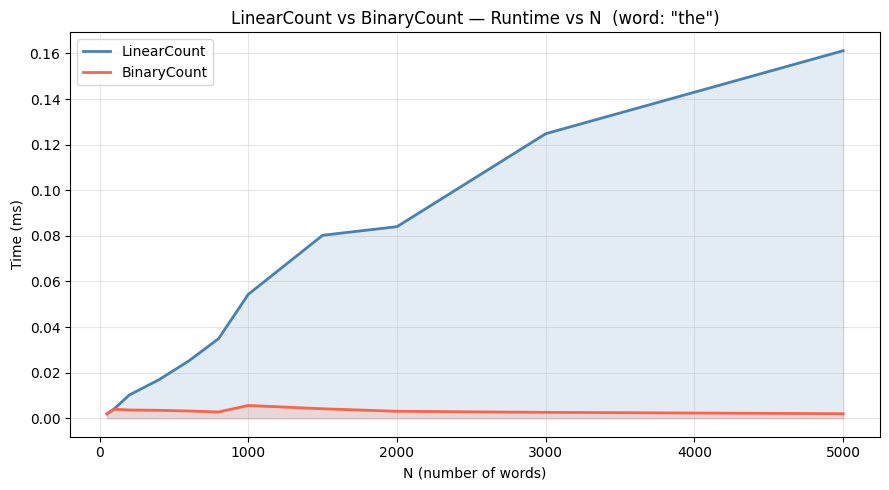

In [3]:
import time
import matplotlib.pyplot as plt

sizes        = [50, 100, 200, 400, 600, 800, 1000, 1500, 2000, 3000, 5000]
runs         = 200
test_word    = "the"
linear_times = []
binary_times = []

base_words = readFileAndSeparateWords("story.txt")

for n in sizes:
    wordArray = sorted((base_words * (n // len(base_words) + 1))[:n])
    pairs = listOfUniqueWordsAndCounts(wordArray)
    tree  = buildTree(pairs)

    t0 = time.perf_counter()
    for _ in range(runs):
        LinearCount(test_word, wordArray)
    linear_times.append((time.perf_counter() - t0) / runs * 1000)

    t0 = time.perf_counter()
    for _ in range(runs):
        Binarycount(test_word, tree)
    binary_times.append((time.perf_counter() - t0) / runs * 1000)

plt.figure(figsize=(9, 5))
plt.plot(sizes, linear_times, color='steelblue', linewidth=2, label='LinearCount')
plt.plot(sizes, binary_times, color='tomato',    linewidth=2, label='BinaryCount')
plt.fill_between(sizes, linear_times, alpha=0.15, color='steelblue')
plt.fill_between(sizes, binary_times, alpha=0.15, color='tomato')
plt.xlabel('N (number of words)')
plt.ylabel('Time (ms)')
plt.title(f'LinearCount vs BinaryCount — Runtime vs N  (word: "{test_word}")')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('performance_plot.png', dpi=150)
plt.show()


## Complexity analysis

**Linear search:**<br>
max = O(1)<br>
In the worst case the algorithm will go through the whole array at most 1 times, and it will return how many times the chosen word appears = O(n) * O(1) = O(n)

**Binary count:**<br>
max = O(log2(n))<br>
The worst case the algorithm will reach the deepest leaf on either the lef or right sides, but still would not go through all the leafs = O(log2(n))

## Unit tests

In [5]:
import unittest

class TestLinearCount(unittest.TestCase):

    def setUp(self):
        self.wordArray = readFileAndSeparateWords("story.txt")

    def test_known_word(self):
        self.assertEqual(LinearCount("the", self.wordArray), 11)

    def test_known_word_contraction(self):
        self.assertEqual(LinearCount("hadn't", self.wordArray), 2)

    def test_word_not_in_file(self):
        self.assertEqual(LinearCount("xyz", self.wordArray), 0)

    def test_empty_string(self):
        self.assertEqual(LinearCount("", self.wordArray), 0)

    def test_single_occurrence(self):
        self.assertEqual(LinearCount("hargrove", self.wordArray), 1)


class TestBinaryCount(unittest.TestCase):

    def setUp(self):
        wordArray   = readFileAndSeparateWords("story.txt")
        pairs       = listOfUniqueWordsAndCounts(wordArray)
        self.tree   = buildTree(pairs)

    def test_known_word(self):
        self.assertEqual(Binarycount("the", self.tree), 11)

    def test_known_word_contraction(self):
        self.assertEqual(Binarycount("hadn't", self.tree), 2)

    def test_word_not_in_file(self):
        self.assertEqual(Binarycount("xyz", self.tree), 0)

    def test_empty_string(self):
        self.assertEqual(Binarycount("", self.tree), 0)

    def test_single_occurrence(self):
        self.assertEqual(Binarycount("hargrove", self.tree), 1)


class TestBothMatch(unittest.TestCase):
    """Ensures LinearCount and BinaryCount always agree."""

    def setUp(self):
        self.wordArray = readFileAndSeparateWords("story.txt")
        pairs          = listOfUniqueWordsAndCounts(self.wordArray)
        self.tree      = buildTree(pairs)

    def test_results_match_for_all_unique_words(self):
        for word in set(self.wordArray):
            self.assertEqual(
                LinearCount(word, self.wordArray),
                Binarycount(word, self.tree),
                msg=f"Mismatch on word: '{word}'"
            )


unittest.main(argv=[""], exit=False, verbosity=2)


test_empty_string (__main__.TestBinaryCount.test_empty_string) ... ok
test_known_word (__main__.TestBinaryCount.test_known_word) ... ok
test_known_word_contraction (__main__.TestBinaryCount.test_known_word_contraction) ... ok
test_single_occurrence (__main__.TestBinaryCount.test_single_occurrence) ... ok
test_word_not_in_file (__main__.TestBinaryCount.test_word_not_in_file) ... ok
test_results_match_for_all_unique_words (__main__.TestBothMatch.test_results_match_for_all_unique_words) ... ok
test_empty_string (__main__.TestLinearCount.test_empty_string) ... ok
test_known_word (__main__.TestLinearCount.test_known_word) ... ok
test_known_word_contraction (__main__.TestLinearCount.test_known_word_contraction) ... ok
test_single_occurrence (__main__.TestLinearCount.test_single_occurrence) ... ok
test_word_not_in_file (__main__.TestLinearCount.test_word_not_in_file) ... ok

----------------------------------------------------------------------
Ran 11 tests in 0.039s

OK
